### Normal Squares, calculated gradients
-   This code creates a series of squares around the all exterior contours of a cell, normal to its outline, that can then be extracted into images
    - There is also a scoring function for judging outputs

### Basic Algorithm Outline:

-   Begin by extracting all external contours of a thresholded image
-   Then for every point along the contours, apply a Gaussian smoothing kernel to X and Y.
    - Sigma is calculated using the number of local maxima/length of contour and some multiplication and division
-   After this then apply np.gradient to X and Y to find dx and dy gradients
    - These can then be combined and normalized into tangent vectors and then normal vectors
-   Use these vectors and Kota's patch calcualation to find width of epithelium at each point
-   Then create sqaures all along the epithelium
    - This is currently done by creating a square at every set step rate and checking these for overlap against each other and allowing squares that do not overlap excessively with past squares
    - There is an additonal check on squares that have excessive (.98%) overlap with existing squares as these are large, undesireable squares
-   The remaining squares are stored and drawn on the original image


-   There is also an evaluation score that checks total coverage of the epithelium and number of blank pixles in the created mask


### Most Up-to_Date Features:
-   There is now one parameter in the function (overlap_thresh)
-   There is an unused Fourier approximation of shape, good at simplifying shape and may require less tuning/automating 
    - Still too unstable for use over Gaussian
    -0.9998 seems to be a very general energy level (static value)
-   Smarter_squares has an additional check and replace feature to catch and remove large squares shortly after their creation
-   Sigma is defined dynamically using a very rough smoothness metric
    - Also look into measures of windiness (ie winding river) to incorporate into score function
        - Sinuosity looks promising

-   This algorithm currenlty just draws squares on the image, but the stored coordinates can be extracted to individual images

MY CODE TO VISUALIZE THIS IS AT THE BOTTOM OF RYANS CODE WHICH IS THE TOP PORTION

In [9]:
import numpy as np
import cv2
from shapely.geometry import Polygon
from scipy.ndimage import gaussian_filter1d
from scipy.signal import argrelextrema
import matplotlib.pyplot as plt


#Read image and threshold for mask:
#This basic method works best with already cropped cells
image1=cv2.imread('input/sox10_highgrade_case3_match1.png')
image1 = cv2.copyMakeBorder(
    image1,
    200, 200,  # Top, Bottom padding
    200, 200,  # Left, Right padding
    borderType=cv2.BORDER_CONSTANT,
    value=[255,255,255])
    #value=[0, 0, 0])  # Black color)




image1_gray = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
_,whole_thresh1=cv2.threshold(image1_gray,240,255,cv2.THRESH_BINARY_INV)


In [10]:
def estimate_curvature_complexity(points):
    """
    Estimate complexity of a contour based on curvature variations.
    """

    if len(points)<5:
        return 1
    
    diffs=np.gradient(points, axis=0)
    curvature=np.linalg.norm(np.gradient(diffs,axis=0),axis=1)

    # Count number of local maxima in curvature (sharp points)
    peaks=argrelextrema(curvature, np.greater)[0]
    
    #Return peaks/points for rough approx of sharp changes
    return len(peaks)/len(points)

In [11]:

def find_external_contours(binary_image):
    '''find all ext`ernal contours of an image'''

    contours,hierarchy=cv2.findContours(binary_image,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

    #This can be used to alter the order contour points are processed in while maintaining order
        #Think [1,2,3,4,5]->[4,5,1,2,3]
        #Set to 0 for no effect, check np documentation for more info
    return [np.roll(contour,0,axis=0) for contour in contours if len(contour)>1]


def gaussian_normals(contours):
    #Initialize list for final normals
    all_normals=[]
    smooth=[]

    #Loop through all contours
    for contour in contours:
        #Reshape contour into point pairings
        points=contour.reshape(-1,2).astype(np.float32)
        
        #Define sigma paramter(std for Gaussian Kernel from contour length)
        #Higher value of sigma means more aggressive smoothing
        #sigma,smoothed=estimate_sigma(points,1,1e-5,60)
        sigma=max(len(contour)*estimate_curvature_complexity(points)//20,1)
        smoothed=gaussian_filter1d(points,sigma,axis=0)
        print(f'Sigma of : {sigma}')
        #Apply Gaussian smoothing to X and Y values, attempting to remove noise from the contour
        #smoothed=np.apply_along_axis(lambda x: gaussian_filter1d(x,sigma,mode='reflect'),axis=0,arr=points)
        #Calculate gradients of X and Y for use then finding the tangent
        gradients=np.gradient(smoothed,axis=0)
        #Find vector norms of tangent vectors
        all_norms=np.linalg.norm(gradients,axis=1,keepdims=True)
        #Divide tangents by norms with numerical stability
        tangent_unit=gradients/(all_norms+1e-8)
        #Initialize normals
        normals=np.zeros_like(tangent_unit)
        
        normals = np.column_stack((-tangent_unit[:, 1], tangent_unit[:, 0]))
        all_normals.append(normals)
        smooth.append(smoothed.reshape(-1,1,2).astype(np.int32))



    return all_normals,smooth

def fourier_normals(contours, energy_threshold=0.995):
    """
    Smooths contours using Fourier transform, then calculates normals.
    """
    all_normals=[]
    smooth=[]
    
    for contour in contours:
        points=contour.reshape(-1,2).astype(np.float32)
        n_points=len(points)
        
        if n_points<5:  # Skip small contours
            all_normals.append(np.zeros_like(points))
            smooth.append(points.reshape(-1,1,2))
            continue
        
        # Apply FFT to x and y coordinates
        x_fft=np.fft.fft(points[:,0])
        y_fft=np.fft.fft(points[:,1])


        complexity=estimate_curvature_complexity(points)
        energy_threshold=min(energy_threshold+complexity*0.001,1)
        
        # Compute energy of frequencies
        energy=np.abs(x_fft)**2 + np.abs(y_fft)**2
        cumulative_energy=np.cumsum(np.sort(energy)[::-1])  # Descending order
        total_energy=cumulative_energy[-1]
        # Determine cutoff where cumulative energy reaches threshold
        cutoff=np.searchsorted(cumulative_energy,total_energy*energy_threshold)
        cutoff=max(1,min(cutoff,n_points//2))
        
        # Create frequency mask
        mask=np.zeros(n_points,dtype=bool)
        mask[:cutoff]=True
        mask[-cutoff:]=True  # Symmetric frequences
        
        # Apply mask
        x_fft_filtered=x_fft*mask
        y_fft_filtered=y_fft*mask
        
        # Inverse FFT
        x_smooth=np.real(np.fft.ifft(x_fft_filtered))
        y_smooth=np.real(np.fft.ifft(y_fft_filtered))
        
        smoothed=np.column_stack([x_smooth,y_smooth])

        # Compute gradients
        gradients = np.gradient(smoothed, axis=0)

        # Normalize to get unit tangents
        norms=np.linalg.norm(gradients,axis=1,keepdims=True)
        tangent_unit=gradients/(norms+1e-8)

        # Compute normals
        normals=np.column_stack((-tangent_unit[:,1],tangent_unit[:,0]))

        all_normals.append(normals)
        smooth.append(smoothed.reshape(-1,1,2).astype(np.int32))#Save smoothed contour for visualization
    
    return all_normals, smooth

def calculate_patch_corners(point, normal, binary_image, extension_factor=1.0, step_size=4, max_length=2048):
    """
    Calculate the corners of a square patch using epithelium width along the normal.

    Args:
        point (np.ndarray): The point on the contour.
        normal (np.ndarray): The normal vector at the point.
        binary_image (np.ndarray): Binary mask of the tissue.
        extension_factor (float): Factor to slightly enlarge the patch (e.g., 1.1 for 10% increase).
        step_size (int): Step size for checking tissue boundaries along the normal.
        max_length (int): Maximum distance to search for epithelium width.

    Returns:
        np.ndarray: The four corners of the square patch.
        int: The computed patch height.
    """
    height, width = binary_image.shape
    point = point.astype(int)

    # generating forward and backward points along the normal
    steps = np.arange(0, max_length, step_size)[:, None]
    points = np.clip(point - steps * normal, 0, [width - 1, height - 1]).astype(int)

    # extracting pixel values along the normal path
    values = binary_image[points[:, 1], points[:, 0]]

    # finding the first background pixel (where value == 0)
    stop = np.where(values == 0)[0]

    # computing distances
    width = stop[0] * step_size if stop.size > 0 else max_length

    # computing total epithelium width and adjust for stroma extension
    extended_length = int(width * extension_factor)
    half_size = extended_length // 2 

    # computing tangent vector (perpendicular to normal)
    tangent = np.array([-normal[1], normal[0]])

    # defining square corners (same logic as `calculate_square_corners`)
    corners = np.array([
        point + (tangent * half_size),
        point - (tangent * half_size),
        point - (tangent * half_size) - (normal * extended_length),
        point + (tangent * half_size) - (normal * extended_length)
    ])

    return corners, extended_length


def calculate_square_overlap(square1,square2):
    '''Calculate overlap ratio between squares'''

    square1=Polygon(square1)
    square2=Polygon(square2)

    if not square1.intersects(square2):
        return 0
    
    intersection_area=square1.intersection(square2).area
    smallest_area=min(square1.area,square2.area)
    return intersection_area/(smallest_area+1e-8)



def create_smarter_squares(contours,normals,binary_image,overlap_thresh):
    '''Create squares that meet overlap thresh with last square'''
    return_squares=[]
    #Loop over all contours and get corresponding normals to point
    for contour, contour_normals in zip(contours,normals):
        points=contour.reshape(-1,2)
        squares=[]
        last_square=None

        #Go over points, evaluating if next square's corner falls outside of range of last square
        for i,point in enumerate(points):

            corners,length=calculate_patch_corners(point,contour_normals[i],binary_image)

            #Prevent poorly sized squares
            #Finding rough area approximation in terms of patch length
            side_length = np.sqrt(cv2.contourArea(contour))
            #Approximately: Want squares less than 50% of contour area, and minimum of 2% area
            if length<side_length*0.02:
                continue
            #Check to see if first square and check agaisnt last square to prevent long loop
            elif last_square is not None and calculate_square_overlap(last_square,corners)>overlap_thresh:
                if Polygon(last_square).area>Polygon(corners).area and calculate_square_overlap(last_square,corners)>.98:
                    squares[-1]=corners
                    last_square=corners
                    continue
                continue

            #Check agasint all squares, prevents issues of larger patches covering thin sections of epithelium next to large ones 
            elif any(calculate_square_overlap(corners, square)>overlap_thresh for square in squares)==True:
                continue
        
            squares.append(corners)
            last_square=corners
        return_squares.append(squares)
    return return_squares

def draw_squares(image,squares_list,color=[255,0,0],thickness=20):
    '''Draw squares on image'''

    result=image.copy()

    for squares in squares_list:
        for square in squares:
            points=square.astype(np.int32)
            cv2.polylines(result,[points],isClosed=True,color=color,thickness=thickness)
        
    return result



def process_contours(image,binary_image,overlap_thresh=0.3):
    """
    Main function to process multiple contours and generate aligned squares along them.
    
    Args:
        image (np.ndarray): Original image
        binary_image (np.ndarray): Binary mask of the shapes
        overlap_thresh (float): Maximum allowed overlap between squares        
    Returns:
        tuple: (processed image, contours, squares_list)
    """
    contours=find_external_contours(binary_image)
    if not contours:
        return TypeError('No contours found')
    
    #Condition check for square creation
    #normals=calculate_contour_normals(contours,smoothing_size)
    normals,smooth=gaussian_normals(contours)
    #normals,smooth=fourier_normals(contours,0.999)
    final_squares_list=create_smarter_squares(contours,normals,binary_image,overlap_thresh=overlap_thresh)

    result = draw_squares(image,final_squares_list)
    #Visualzie smoothed contour

    try:
        cv2.drawContours(result,smooth,-1,(0,255,0),30)
    except:
        print('No smoothed contour to show')
    
    return result, contours, final_squares_list, normals





In [12]:
def check_metrics(binary_image,contours):
    '''Evaluate fit of normal squares using mask'''

    total_white_pixels=(binary_image>0).sum()
    squares_mask=np.zeros_like(binary_image,dtype=np.uint8)

    weight_coverage=0.8
    weight_black_pixels=0.2
    
    #For all squares in all contours, use them to create a mask
    for contour in contours:
        for square in contour:
            square=np.array(square,dtype=np.int32).reshape(-1,1,2)
            cv2.fillPoly(squares_mask,[square],255)

    mask_pixels=np.count_nonzero(squares_mask>0)

    #Find coverage and non-epitheliuem pixel values 

    covered_white_pixels=np.count_nonzero((squares_mask>0)&(binary_image>0))
    covered_black_pixels=np.count_nonzero((squares_mask>0)&(binary_image==0))

    total_coverage=(covered_white_pixels/total_white_pixels*100)
    black_pixel_percent=(covered_black_pixels/mask_pixels*100)
    score=weight_coverage*total_coverage+weight_black_pixels*(100-black_pixel_percent)
    
    return total_coverage,black_pixel_percent,score
        


Sigma of : 1.0
Sigma of : 1
Sigma of : 1.0
Sigma of : 1.0
Sigma of : 6.0
Sigma of : 2.0
Sigma of : 1
Sigma of : 34.0
Total Coverage: 92.63


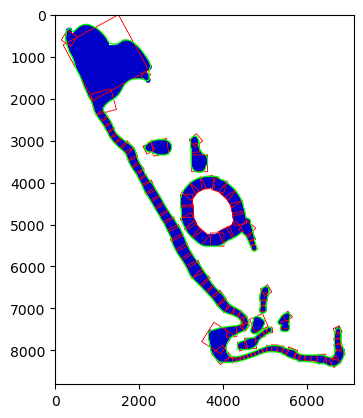

In [13]:
result,contours,final_squares,normals=process_contours(image1,whole_thresh1,0.2)
total_coverage,_,_=check_metrics(whole_thresh1,final_squares)
plt.imshow(result)
print(f'Total Coverage: {total_coverage:.2f}')



In [14]:
def visualize_tangents(image,contours,normals,tangent_length=200,color=(255,0,0),thickness=30,step=90):
    """
    Visualize tangent vectors along contours.
    """
    result=image.copy()
    
    for contour,contour_normals in zip(contours, normals):
        points=contour.reshape(-1, 2)
        
        for i in range(0,len(points),step):
            tangent=np.array([-contour_normals[i][1], contour_normals[i][0]])  # Rotate normal by 90 degrees
            
            tangent=tangent*tangent_length//2
            
            start_point=tuple((points[i]-tangent).astype(int))
            end_point=tuple((points[i]+tangent).astype(int))
            
            cv2.line(result,start_point,end_point,color,thickness)
    
    return result

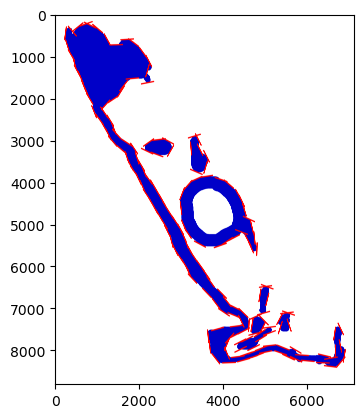

In [15]:
plt.imshow(visualize_tangents(image1.copy(),contours,normals,300,step=120,thickness=30))

Sigma of : 1.0
Sigma of : 1
Sigma of : 1.0
Sigma of : 1.0
Sigma of : 6.0
Sigma of : 2.0
Sigma of : 1
Sigma of : 34.0


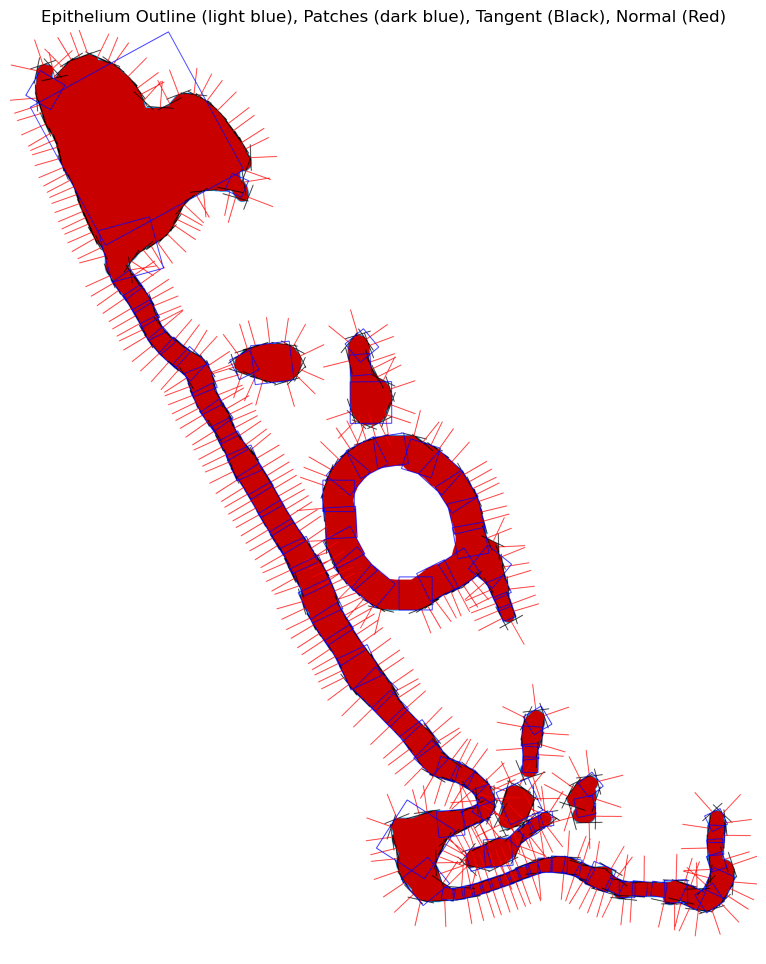

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_tangents(image, contours, normals, tangent_length=250, color=(0, 0, 0), thickness=5, step=50):

    result = image.copy()

    for contour, contour_normals in zip(contours, normals):
        points = contour.reshape(-1, 2)

        for i in range(0, len(points), step):
            tangent = np.array([-contour_normals[i][1], contour_normals[i][0]])  # Rotate normal by 90 degrees
            
            start_point = tuple((points[i] - tangent * tangent_length // 2).astype(int))
            end_point = tuple((points[i] + tangent * tangent_length // 2).astype(int))

            cv2.line(result, start_point, end_point, color, thickness)

    return result


def visualize_normals(image, contours, normals, normal_length=250, color=(0, 0, 255), thickness=5, step=50):

    result = image.copy()

    for contour, contour_normals in zip(contours, normals):
        points = contour.reshape(-1, 2)

        for i in range(0, len(points), step):
            normal = contour_normals[i]

            start_point = tuple(points[i].astype(int))
            end_point = tuple((points[i] + normal * normal_length).astype(int))

            cv2.line(result, start_point, end_point, color, thickness)

    return result


def visualize_patches(image, patches, color=(255, 0, 0), thickness=5):

    result = image.copy()

    for patch_group in patches:
        for patch in patch_group:
            points = patch.astype(np.int32)
            cv2.polylines(result, [points], isClosed=True, color=color, thickness=thickness)

    return result


def visualize_epithelium_outline(image, contours, color=(255, 165, 0), thickness=5):

    result = image.copy()
    cv2.drawContours(result, contours, -1, color, thickness)
    return result


# Process the contours and patches
result, contours, final_squares, normals = process_contours(image1, whole_thresh1, overlap_thresh=0.2)

# Create separate images for each visualization
epithelium_outline_image = visualize_epithelium_outline(image1.copy(), contours, color=(255, 165, 0))  
tangent_image = visualize_tangents(epithelium_outline_image.copy(), contours, normals, step=50)  
normal_image = visualize_normals(tangent_image.copy(), contours, normals, step=50)  
patches_image = visualize_patches(normal_image.copy(), final_squares, color=(255, 0, 0))  

# Display the final output
plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(patches_image, cv2.COLOR_BGR2RGB))
plt.title("Epithelium Outline (light blue), Patches (dark blue), Tangent (Black), Normal (Red)")
plt.axis("off")
plt.show()